In [5]:
import healpy as hp
import numpy as np

# ── 1) LOAD YOUR HEALPIX MAP ────────────────────────────────────────────────────
# Replace 'mymap.fits' with your filename, or generate m however you like.
m = hp.read_map('star_map_with_spot.fits')
nside = hp.get_nside(m)
npix  = hp.nside2npix(nside)


AttributeError: 'numpy.ndarray' object has no attribute 'unseen'

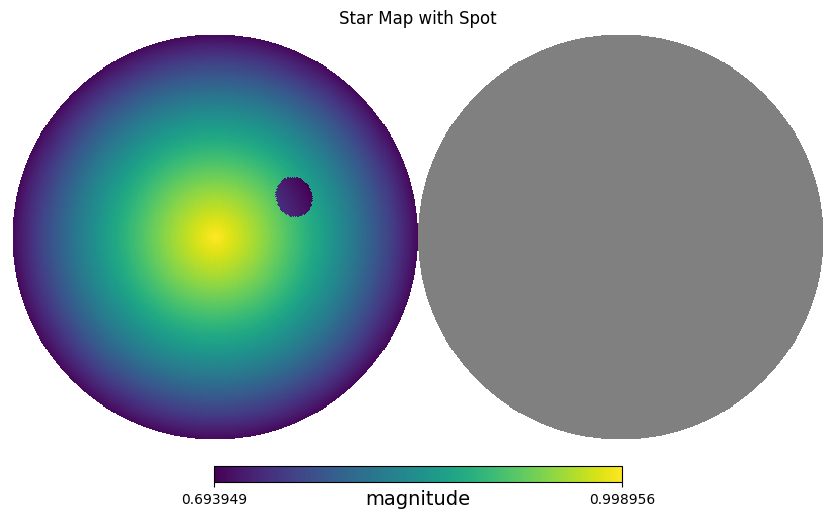

In [28]:
hp.orthview(m, title='Star Map with Spot', unit='magnitude',)

Observed (orthographic) flux at lat=0°, lon=0°: 1.185203e+00


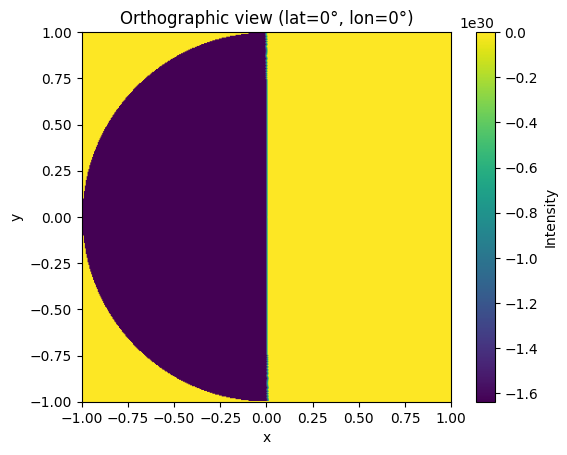

In [34]:
# ── 2) DEFINE OBSERVER DIRECTION (lat, lon) = (0°, 0°) ─────────────────────────
lat_deg = 0.0
lon_deg = 0.0
# convert to colatitude & radians
theta0 = np.radians(90.0 - lat_deg)   # = 90° → np.radians(90)
phi0   = np.radians(lon_deg)          # = 0° → 0 radians

# build the Rotator: rotate (φ0,θ0,0) so that (lat,lon) comes to the +z axis
rot = hp.Rotator(rot=(phi0, theta0, 0.0), inv=False, deg=False)

# ── 3) GET PIXEL VECTORS & ROTATE ──────────────────────────────────────────────
# pix2vec returns (x,y,z) arrays; stack to (npix,3)
vecs = np.vstack(hp.pix2vec(nside, np.arange(npix))).T  # shape (npix,3)
# split components
x, y, z = vecs[:,0], vecs[:,1], vecs[:,2]
# apply rotation matrix
rotmat      = rot.mat
x_r, y_r, z_r = rotateVector(rotmat, x, y, z)
# reassemble
vecs_rot = np.vstack((x_r, y_r, z_r)).T

# ── 4) MASK VISIBLE PIXELS ────────────────────────────────────────────────────
visible = vecs_rot[:,0] > 0

# ── 5) PROJECT TO 2D & GET WEIGHTS ────────────────────────────────────────────
x2d       = vecs_rot[visible, 1]
y2d       = vecs_rot[visible, 2]
I_vis     = m[visible]
cos_theta = vecs_rot[visible, 0]   # dot(n,ẑ)

# ── 6) INTEGRATE OBSERVED FLUX ────────────────────────────────────────────────
pixel_area = 4*np.pi / npix
F_values= I_vis * cos_theta * pixel_area

F_obs = np.sum(F_values[I_vis>0])
print(f"Observed (orthographic) flux at lat=0°, lon=0°: {F_obs:e}")

# ── OPTIONAL: BUILD A CARTESIAN IMAGE ─────────────────────────────────────────
N = 400
xs = np.linspace(-1, 1, N)
ys = np.linspace(-1, 1, N)
img = np.zeros((N, N))
for i, xx in enumerate(xs):
    for j, yy in enumerate(ys):
        if xx*xx + yy*yy <= 1:
            zz      = np.sqrt(1 - xx*xx - yy*yy)
            theta   = np.arccos(zz)
            phi     = np.mod(np.arctan2(yy, xx), 2*np.pi)
            img[j,i]= hp.get_interp_val(m, theta, phi)
import matplotlib.pyplot as plt
plt.imshow(img, origin='lower', extent=[-1,1,-1,1])
plt.xlabel('x'); plt.ylabel('y')
plt.title('Orthographic view (lat=0°, lon=0°)')
plt.colorbar(label='Intensity')
plt.show()